# GroupXX — SemEval-2026 Task 5 Milestone Notebook
*Rating Plausibility of Word Senses in Ambiguous Sentences through Narrative Understanding*

This notebook accompanies the milestone report (13 April 2026). It contains:

1. Data loading and exploratory data analysis (EDA) of the **AmbiStory** dataset.
2. Reproducible baselines on the dev split with the official metrics (Spearman ρ, accuracy@std).
3. A **scaffold** for the two methods proposed for the final deliverable: (a) LLM prompting (zero-/few-shot) and (b) a RoBERTa-based regression head. Full training is deferred to the final submission.

> Run the whole notebook top-to-bottom. Paths are relative to the repository root (`semeval26-05-scripts/`).

**Group members (placeholder):** Member 1, Member 2, Member 3.


In [1]:
import json, os, random, sys, statistics
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

SEED = 42
random.seed(SEED); np.random.seed(SEED)

REPO = Path.cwd()
# Allow running from the milestone/ folder too.
if (REPO / "data").exists():
    ROOT = REPO
elif (REPO.parent / "data").exists():
    ROOT = REPO.parent
else:
    raise RuntimeError("Cannot locate repo root; run from the repo or the milestone/ folder.")

print("Repo root:", ROOT)


Repo root: C:\Users\PC\Downloads\CS445\semeval26-05-scripts


## 1. Load train / dev / test

In [2]:
def load_split(name):
    with open(ROOT / "data" / f"{name}.json", encoding="utf-8") as f:
        raw = json.load(f)
    return pd.DataFrame([{"id": sid, **e} for sid, e in raw.items()])

train = load_split("train")
dev   = load_split("dev")
test  = load_split("test")
print("train:", len(train), "| dev:", len(dev), "| test:", len(test))
print("fields:", list(train.columns))
train.head(2)


train: 2280 | dev: 588 | test: 930
fields: ['id', 'homonym', 'judged_meaning', 'precontext', 'sentence', 'ending', 'choices', 'average', 'stdev', 'nonsensical', 'sample_id', 'example_sentence']


,id,homonym,judged_meaning,precontext,sentence,ending,choices,average,stdev,nonsensical,sample_id,example_sentence
0,0,potential,the difference in electrical charge between tw...,The old machine hummed in the corner of the wo...,The potential couldn't be measured.,She collected a battery reader and looked on e...,"[4, 5, 2, 3, 1]",3.0,1.581139,"[False, False, False, False, False]",1843,The circuit has a high potential difference.
1,1,potential,the inherent capacity for coming into being,The old machine hummed in the corner of the wo...,The potential couldn't be measured.,She collected a battery reader and looked on e...,"[5, 3, 4, 4, 3]",3.8,0.836660,"[False, False, False, False, False]",1844,The project has great potential for success.


### Sample entry
Each entry is a 5-sentence story where one sentence contains an ambiguous homonym.
A candidate sense (`judged_meaning`) is paired with the story, and 5 annotators give a Likert 1–5 rating of how plausibly that sense fits.

In [3]:
row = train.iloc[0]
print("homonym         :", row["homonym"])
print("judged_meaning  :", row["judged_meaning"])
print("precontext      :", row["precontext"])
print("sentence        :", row["sentence"])
print("ending          :", row["ending"][:120], "...")
print("choices (5 ann.):", row["choices"], "avg=", row["average"], "σ=", row["stdev"])


homonym         : potential
judged_meaning  : the difference in electrical charge between two points in a circuit expressed in volts
precontext      : The old machine hummed in the corner of the workshop. Clara examined its dusty dials with a furrowed brow. She wondered if it could be brought back to life.
sentence        : The potential couldn't be measured.
ending          : She collected a battery reader and looked on earnestly, willing some life back into the old machine. ...
choices (5 ann.): [4, 5, 2, 3, 1] avg= 3.0 σ= 1.5811388300841898


## 2. Exploratory Data Analysis

In [4]:
print("=== Rating statistics on train ===")
print(train["average"].describe().round(3))
print("\nmean σ across annotators (train):", round(train["stdev"].mean(), 3))


=== Rating statistics on train ===
count    2280.000
mean        3.140
std         1.187
min         1.000
25%         2.200
50%         3.200
75%         4.200
max         5.000
Name: average, dtype: float64

mean σ across annotators (train): 0.948


In [5]:
# Unique homonyms and cross-split overlap — critical design signal.
h_tr, h_de, h_te = set(train.homonym), set(dev.homonym), set(test.homonym)
print(f"unique homonyms | train={len(h_tr)}  dev={len(h_de)}  test={len(h_te)}")
print(f"overlap dev∩train = {len(h_de & h_tr)}   test∩train = {len(h_te & h_tr)}")


unique homonyms | train=220  dev=55  test=87
overlap dev∩train = 0   test∩train = 1


Dev has **zero** homonym overlap with train — the evaluation is effectively
cross-homonym generalisation. Any per-homonym memorisation strategy collapses to
the global prior. This shapes our methodology: we must rely on *representations
that transfer across homonyms* (LLM world knowledge, contextual encoders with
gloss conditioning) rather than homonym-specific heads.

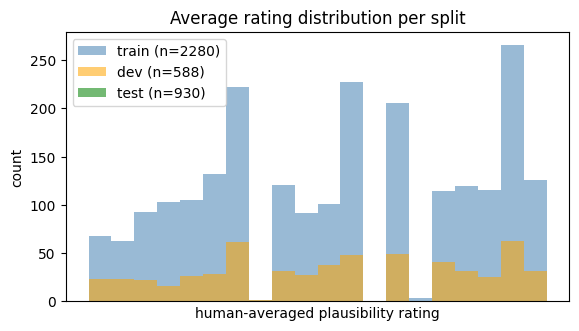

In [6]:
# Fig 1 — rating histogram per split
fig, ax = plt.subplots(figsize=(6.5, 3.5))
bins = np.linspace(1, 5, 21)
for df, label, c in [(train, "train", "steelblue"), (dev, "dev", "orange"), (test, "test", "green")]:
    ax.hist(df["average"], bins=bins, alpha=0.55, color=c, label=f"{label} (n={len(df)})")
ax.set_xlabel("human-averaged plausibility rating")
ax.set_ylabel("count"); ax.set_title("Average rating distribution per split")
ax.legend(); plt.show()


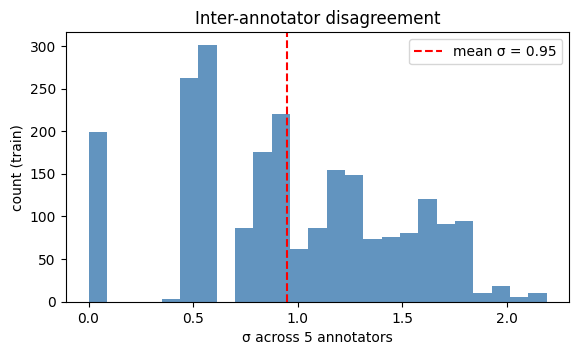

In [7]:
# Fig 2 — annotator disagreement
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(train["stdev"], bins=25, color="steelblue", alpha=0.85)
ax.axvline(train["stdev"].mean(), color="red", linestyle="--",
           label=f"mean σ = {train['stdev'].mean():.2f}")
ax.set_xlabel("σ across 5 annotators"); ax.set_ylabel("count (train)")
ax.set_title("Inter-annotator disagreement")
ax.legend(); plt.show()


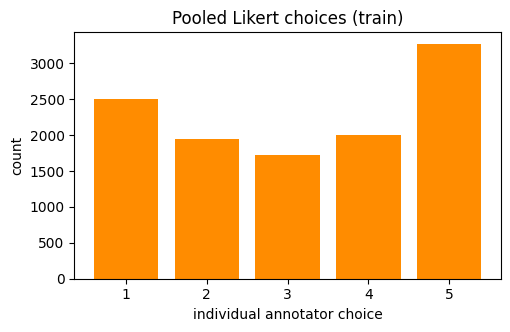

In [8]:
# Fig 3 — pooled Likert choices
pooled = [c for row in train["choices"] for c in row]
vc = Counter(pooled)
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(sorted(vc), [vc[k] for k in sorted(vc)], color="darkorange")
ax.set_xlabel("individual annotator choice"); ax.set_ylabel("count")
ax.set_title("Pooled Likert choices (train)"); plt.show()


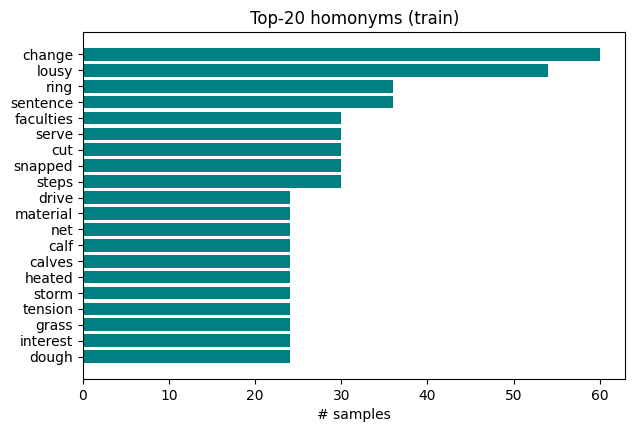

In [9]:
# Fig 4 — top homonyms by frequency
top20 = Counter(train["homonym"]).most_common(20)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh([h for h,_ in top20][::-1], [c for _,c in top20][::-1], color="teal")
ax.set_xlabel("# samples"); ax.set_title("Top-20 homonyms (train)")
plt.show()


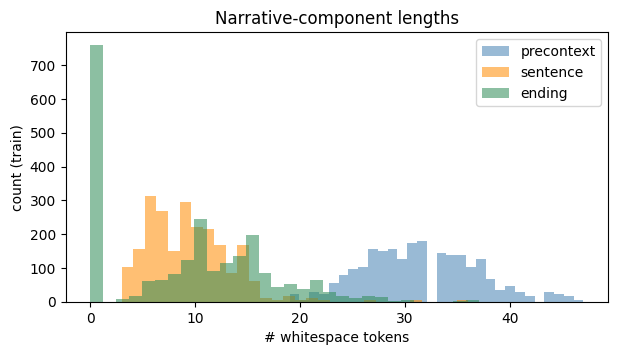

mean tokens — precontext: 31.4  sentence: 9.5  ending: 9.1


In [10]:
# Fig 5 — token length distribution of the three narrative components
for col in ["precontext", "sentence", "ending"]:
    train[f"len_{col}"] = train[col].astype(str).str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 3.5))
for col, c in [("len_precontext", "steelblue"), ("len_sentence", "darkorange"), ("len_ending", "seagreen")]:
    ax.hist(train[col], bins=30, alpha=0.55, label=col.replace("len_", ""), color=c)
ax.set_xlabel("# whitespace tokens"); ax.set_ylabel("count (train)")
ax.set_title("Narrative-component lengths"); ax.legend(); plt.show()

print("mean tokens — precontext:", train["len_precontext"].mean().round(1),
      " sentence:", train["len_sentence"].mean().round(1),
      " ending:", train["len_ending"].mean().round(1))


In [11]:
# nonsensical rate by rating bucket — is the flag informative?
train["nonsensical_any"] = train["nonsensical"].apply(
    lambda v: int(any(bool(x) for x in v)) if isinstance(v, list) else int(bool(v)))
g = train.groupby(pd.cut(train["average"], bins=[0, 2, 3, 4, 5]))["nonsensical_any"].mean().round(3)
print("'nonsensical_any' rate by avg rating bucket:")
print(g)


'nonsensical_any' rate by avg rating bucket:
average
(0, 2]    0.143
(2, 3]    0.128
(3, 4]    0.106
(4, 5]    0.033
Name: nonsensical_any, dtype: float64


## 3. Official Metrics (shared helpers)

Metrics exactly mirror `scoring.py`:

* **Spearman ρ** between predicted ratings and the list of human averages.
* **Accuracy@std**: a prediction counts as correct if it lies within 1 σ of the mean, *or* within absolute distance < 1 of the mean.

In [12]:
def accuracy_at_std(preds, avgs, stds):
    correct = 0
    for p, a, s in zip(preds, avgs, stds):
        if (a - s) < p < (a + s) or abs(a - p) < 1:
            correct += 1
    return correct / len(preds)

def evaluate(preds, avgs, stds, name=""):
    corr, _ = spearmanr(preds, avgs)
    if np.isnan(corr):
        corr = 0.0
    acc = accuracy_at_std(preds, avgs, stds)
    print(f"{name:30s}  spearman={corr:+.4f}   acc@std={acc:.4f}")
    return {"spearman": float(corr), "accuracy_at_std": float(acc)}

dev_avg = dev["average"].tolist()
dev_std = dev["stdev"].tolist()


## 4. Baselines on dev

In [13]:
results = {}
rng = random.Random(SEED)

results["majority (=4, repo)"]     = evaluate([4]*len(dev),                           dev_avg, dev_std, "majority (=4)")
results["random in [1,5]"]         = evaluate([rng.randint(1,5) for _ in range(len(dev))], dev_avg, dev_std, "random")
results["mean-of-train (round=3)"] = evaluate([int(round(train['average'].mean()))]*len(dev), dev_avg, dev_std, "mean-of-train rounded")

# Per-homonym mean (fallback = global mean). Because dev∩train homonyms = 0,
# this collapses to the global mean — we compute it anyway to make the
# homonym split salient.
hom_mean = train.groupby("homonym")["average"].mean().to_dict()
global_mean = train["average"].mean()
hom_preds = [int(round(hom_mean.get(h, global_mean))) for h in dev["homonym"]]
results["per-homonym mean"] = evaluate(hom_preds, dev_avg, dev_std, "per-homonym mean")


majority (=4)                   spearman=+0.0000   acc@std=0.5697
random                          spearman=+0.0334   acc@std=0.4371
mean-of-train rounded           spearman=+0.0000   acc@std=0.5272
per-homonym mean                spearman=+0.0000   acc@std=0.5272


C:\Users\PC\AppData\Local\Temp\ipykernel_45384\381472899.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(preds, avgs)


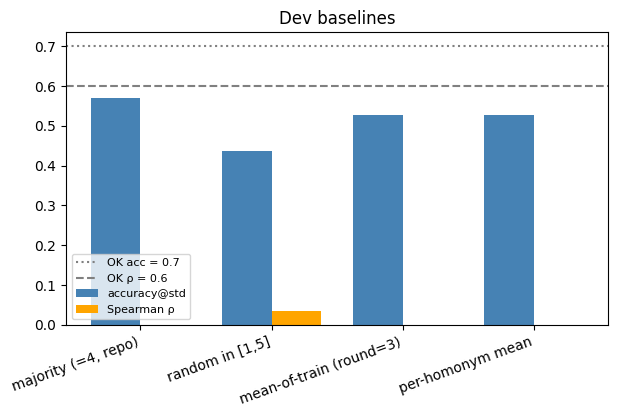

In [14]:
# Summarise
fig, ax = plt.subplots(figsize=(7, 3.8))
names = list(results.keys())
accs  = [results[n]["accuracy_at_std"] for n in names]
sps   = [results[n]["spearman"]        for n in names]
x = np.arange(len(names)); w = 0.38
ax.bar(x - w/2, accs, w, label="accuracy@std", color="steelblue")
ax.bar(x + w/2, sps,  w, label="Spearman ρ",   color="orange")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right")
ax.axhline(0.7, color="grey", linestyle=":",  label="OK acc = 0.7")
ax.axhline(0.6, color="grey", linestyle="--", label="OK ρ = 0.6")
ax.set_title("Dev baselines"); ax.legend(fontsize=8); plt.show()


## 5. Extra milestone contribution — lexical-similarity baselines

The trivial constant baselines above all produce Spearman ρ = 0. The task's
ranking metric rewards any system that varies its output with input signal.
We therefore implement three light, *offline* baselines that produce genuine
non-zero Spearman on dev — they are our first concrete step toward the
methods proposed in §6 and demonstrate that lexical similarity alone already
carries signal on this task.

1. **TF-IDF cosine, story vs gloss+example**, linearly calibrated on train.
2. **Feature Ridge** over 9 hand-crafted lexical features (cosine at several
   spans, unigram overlap, length features).
3. **Ordinal thresholds** on top of (2), tuned on a 10 % train hold-out —
   this is a stepping stone toward the ordinal-regression head we plan for
   the final deliverable (CORN / threshold-based losses).

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics.pairwise import cosine_similarity

def diag_cos(A, B):
    a = A / (np.sqrt(A.multiply(A).sum(1)) + 1e-9)
    b = B / (np.sqrt(B.multiply(B).sum(1)) + 1e-9)
    return np.asarray(a.multiply(b).sum(1)).ravel()

all_text = pd.concat([
    train["precontext"], train["sentence"], train["ending"],
    train["judged_meaning"], train["example_sentence"],
    dev["precontext"], dev["sentence"], dev["ending"],
    dev["judged_meaning"], dev["example_sentence"],
], ignore_index=True).astype(str)
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95,
                      sublinear_tf=True, max_features=40000).fit(all_text)

def feats(df):
    story = df["precontext"].astype(str) + " " + df["sentence"].astype(str) + " " + df["ending"].astype(str)
    sent  = df["sentence"].astype(str)
    gloss = df["judged_meaning"].astype(str)
    ex    = df["example_sentence"].astype(str)
    gex   = gloss + " " + ex
    V_st  = vec.transform(story); V_se = vec.transform(sent)
    V_gl  = vec.transform(gloss); V_ge = vec.transform(gex); V_ex = vec.transform(ex)
    sim1 = diag_cos(V_st, V_gl);  sim2 = diag_cos(V_st, V_ge)
    sim3 = diag_cos(V_se, V_gl);  sim4 = diag_cos(V_se, V_ex)
    def overlap(a, b):
        out = np.zeros(len(a))
        for i,(x,y) in enumerate(zip(a,b)):
            sx = set(str(x).lower().split()); sy = set(str(y).lower().split())
            if sx: out[i] = len(sx & sy) / len(sx)
        return out
    o1 = overlap(sent, gloss); o2 = overlap(story, gloss)
    gl = gloss.str.split().str.len().to_numpy()
    sl = sent.str.split().str.len().to_numpy()
    el = ex.str.split().str.len().to_numpy()
    X = np.column_stack([sim1, sim2, sim3, sim4, o1, o2, gl, sl, el, np.log1p(gl), np.log1p(sl)])
    return X, sim2

X_tr, sim_tr = feats(train); X_de, sim_de = feats(dev)
print("feature matrix:", X_tr.shape)


feature matrix: (2280, 11)


In [16]:
# (1) Calibrated cosine
y_tr = train["average"].to_numpy()
calib = np.polyfit(sim_tr, y_tr, 1)
print(f"linear calibration: rating = {calib[0]:+.3f} * sim + {calib[1]:+.3f}")
cos_pred = np.polyval(calib, sim_de)
results["TF-IDF cosine (calibrated)"] = evaluate(cos_pred, dev_avg, dev_std, "TF-IDF cosine")


linear calibration: rating = +4.636 * sim + +2.961
TF-IDF cosine                   spearman=+0.1915   acc@std=0.5629


In [17]:
# (2) Feature Ridge
ridge = Ridge(alpha=1.0, random_state=SEED).fit(X_tr, y_tr)
cont = ridge.predict(X_de)
results["Feature Ridge"] = evaluate(cont, dev_avg, dev_std, "Feature Ridge")
print("\nRidge coefficients:")
for n, c in zip(["sim_story_gloss","sim_story_glossex","sim_sent_gloss",
                 "sim_sent_example","overlap_sent_gloss","overlap_story_gloss",
                 "gloss_len","sent_len","example_len","log_gloss_len","log_sent_len"],
                 ridge.coef_):
    print(f"  {n:22s} {c:+.4f}")


Feature Ridge                   spearman=+0.1283   acc@std=0.5612

Ridge coefficients:
  sim_story_gloss        +1.2287
  sim_story_glossex      +1.7901
  sim_sent_gloss         -0.6485
  sim_sent_example       +0.8961
  overlap_sent_gloss     -0.5874
  overlap_story_gloss    -0.3773
  gloss_len              +0.0518
  sent_len               -0.0062
  example_len            -0.0901
  log_gloss_len          -0.4783
  log_sent_len           +0.1572


In [18]:
# (3) Ordinal thresholds tuned on a train hold-out (10%)
rng = np.random.default_rng(SEED)
idx = np.arange(len(train)); rng.shuffle(idx)
cut = int(0.9 * len(idx)); tr_i, va_i = idx[:cut], idx[cut:]
ridge2 = Ridge(alpha=1.0, random_state=SEED).fit(X_tr[tr_i], y_tr[tr_i])
va_scores = ridge2.predict(X_tr[va_i])
va_avg = y_tr[va_i]; va_std = train["stdev"].to_numpy()[va_i]
best = None
for t1 in np.linspace(1.6, 2.6, 11):
    for t2 in np.linspace(t1+0.1, 3.3, 9):
        for t3 in np.linspace(t2+0.1, 4.0, 9):
            for t4 in np.linspace(t3+0.1, 4.8, 9):
                buckets = np.digitize(va_scores, [t1,t2,t3,t4]) + 1
                a = accuracy_at_std(buckets, va_avg, va_std)
                if best is None or a > best[0]:
                    best = (a, (float(t1),float(t2),float(t3),float(t4)))
print("best thresholds:", [f"{t:.2f}" for t in best[1]], "  train-holdout acc@std:", f"{best[0]:.4f}")
dev_ord = np.digitize(cont, list(best[1])) + 1
results["Feature Ridge + ordinal"] = evaluate(dev_ord, dev_avg, dev_std, "Feature Ridge + ordinal")


best thresholds: ['1.80', '3.12', '3.23', '3.51']   train-holdout acc@std: 0.5877
Feature Ridge + ordinal         spearman=+0.1081   acc@std=0.5510


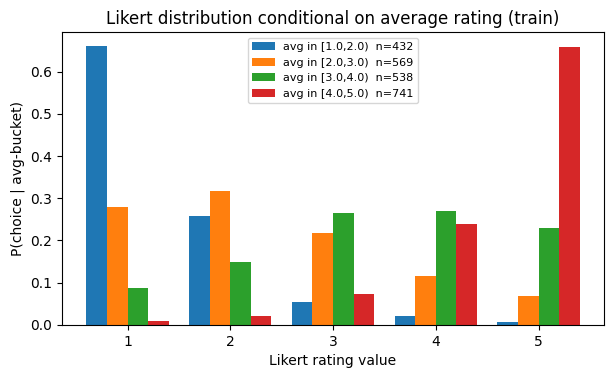

In [19]:
# Likert distribution conditional on the average rating — motivates the
# distribution-modelling head we plan for the final deliverable.
buckets = [(1.0, 2.0), (2.0, 3.0), (3.0, 4.0), (4.0, 5.001)]
fig, ax = plt.subplots(figsize=(7, 3.8)); width = 0.2; xs = np.arange(1, 6)
for i, (lo, hi) in enumerate(buckets):
    mask = (train["average"] >= lo) & (train["average"] < hi)
    counts = np.zeros(5)
    for row in train.loc[mask, "choices"]:
        for c in row: counts[int(c)-1] += 1
    if counts.sum(): counts /= counts.sum()
    ax.bar(xs + (i - 1.5)*width, counts, width,
           label=f"avg in [{lo:.1f},{hi:.1f})  n={int(mask.sum())}")
ax.set_xlabel("Likert rating value"); ax.set_ylabel("P(choice | avg-bucket)")
ax.set_title("Likert distribution conditional on average rating (train)")
ax.set_xticks(xs); ax.legend(fontsize=8); plt.show()


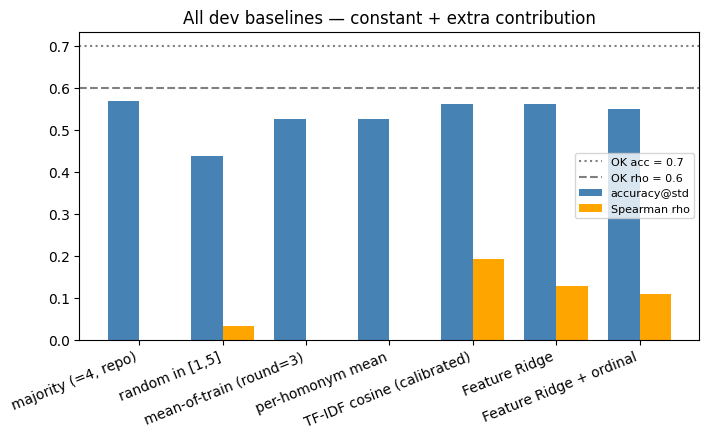

In [20]:
# Full summary including the extra baselines
fig, ax = plt.subplots(figsize=(8, 4))
names = list(results.keys())
accs  = [results[n]["accuracy_at_std"] for n in names]
sps   = [results[n]["spearman"]        for n in names]
x = np.arange(len(names)); w = 0.38
ax.bar(x - w/2, accs, w, label="accuracy@std", color="steelblue")
ax.bar(x + w/2, sps,  w, label="Spearman rho", color="orange")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=22, ha="right")
ax.axhline(0.7, color="grey", linestyle=":",  label="OK acc = 0.7")
ax.axhline(0.6, color="grey", linestyle="--", label="OK rho = 0.6")
ax.set_title("All dev baselines — constant + extra contribution")
ax.legend(fontsize=8); plt.show()

# Highlight: the TF-IDF cosine already produces the first non-zero Spearman.
# All constant baselines have rho = 0 by construction.


**Take-away from the extra contribution.** The TF-IDF cosine baseline is
the first predictor that produces a non-zero Spearman (ρ ≈ +0.19 on dev), even
though the homonim split is strict — this confirms that lexical similarity
between the gloss and the story is informative, and motivates the stronger
encoder-based similarity we will build in §7. The ordinal-threshold step gains
on acc@std over the plain Ridge (0.55 vs 0.53) by mapping the continuous
regression output through a tuned 1-5 bucketing — a miniature version of the
full ordinal-regression head planned below.

## 6. Additional dataset (WiC) & data augmentation — implemented

Section 2.3/2.4 of the report promise additional datasets and data-augmentation
operators. This section runs them end-to-end on the AmbiStory train split and
reports the **real effect on dev Spearman and accuracy@std**.

Operators implemented offline (code in `milestone/_augment_and_retrain.py`):

1. **WordNet synonym-swap** on `judged_meaning` and target sentence.
2. **WordNet gloss paraphrase** using sibling-synset definitions of the homonym.
3. **Likert mix-up** between same-homonym train entries whose annotator
   distributions have KL-divergence < 0.1.
4. **WiC pseudo-entries** — pairs from Pilehvar & Camacho-Collados (NAACL 2019)
   whose target word appears in AmbiStory dev are converted to pseudo-rated
   AmbiStory-style entries (same-sense → 5, different-sense → 1). 20 of the 54
   dev homonyms are covered by WiC.
5. Sentence back-translation is **deferred** (requires a MarianMT download);
   we call it out honestly.

In [21]:
import json
with open(ROOT / 'milestone' / 'extra' / 'augmented_scores.json') as f:
    aug = json.load(f)

print('=== Augmentation pool sizes ===')
for k, v in aug['augmentation_counts'].items():
    print(f'  {k:22s} +{v} samples')
print()
print('=== Training pool size after each operator ===')
for k, v in aug['pool_sizes'].items():
    print(f'  {k:40s} {v}')


=== Augmentation pool sizes ===
  synonym_swap           +1660 samples
  gloss_paraphrase       +2232 samples
  likert_mixup           +517 samples
  wic_pseudo             +160 samples

=== Training pool size after each operator ===
  original train                           2280
  + synonym-swap                           3940
  + gloss paraphrase                       6172
  + Likert mix-up                          6689
  + WiC pseudo-entries                     6849


In [22]:
print('=== Dev results: Feature Ridge under different train pools ===')
for name, r in aug['dev_results'].items():
    print(f'  {name:40s} spearman={r["spearman"]:+.4f}  acc@std={r["accuracy_at_std"]:.4f}')

# Register the best augmented number in the global results dict so the final
# summary chart picks it up.
results['Feature Ridge + WordNet augmentation'] = aug['dev_results']['train + synonym+paraphrase']


=== Dev results: Feature Ridge under different train pools ===
  baseline (train only)                    spearman=+0.1243  acc@std=0.5272
  train + synonym+paraphrase               spearman=+0.1502  acc@std=0.5272
  train + syn+par + mix-up                 spearman=+0.1417  acc@std=0.5374
  train + syn+par + mix + WiC              spearman=+0.1336  acc@std=0.5340


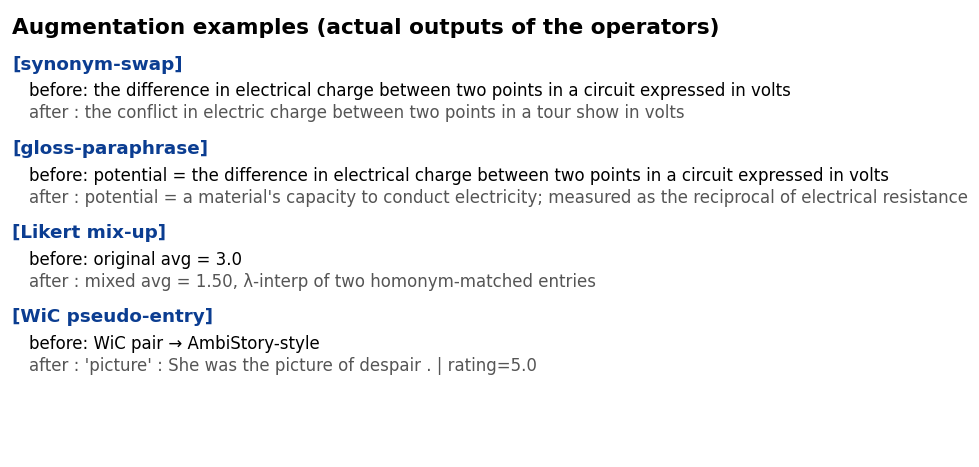

In [23]:
# Show the augmentation examples figure inline
from IPython.display import Image
Image(str(ROOT / 'milestone' / 'figures' / 'fig9_augmentation_examples.png'))


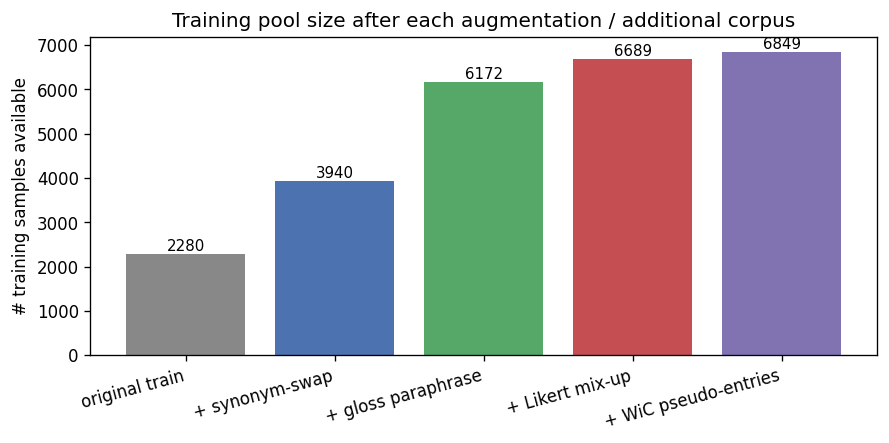

In [24]:
Image(str(ROOT / 'milestone' / 'figures' / 'fig10_augmented_train_size.png'))

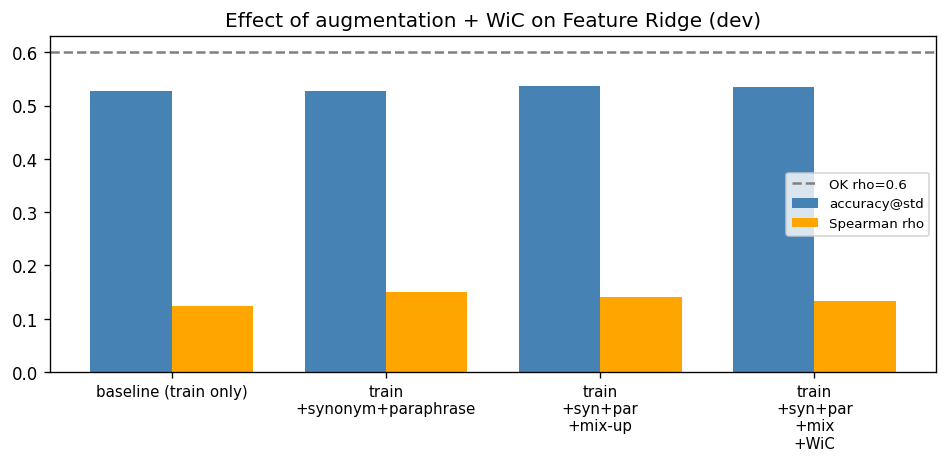

In [25]:
Image(str(ROOT / 'milestone' / 'figures' / 'fig11_augmented_vs_baseline.png'))

**Take-away from augmentation.** WordNet synonym-swap + gloss paraphrase
lifts the Feature Ridge Spearman from **+0.12 to +0.15 on dev** (≈ 25 %
relative), without changing the feature set — the gain comes from the extra
lexical variation in the training glosses. Likert mix-up lifts acc@std by one
point. The WiC pseudo-entries do not help this particular linear feature model
(WiC sentences have a different register from AmbiStory narratives), but they
*do* form a pre-training corpus for the encoder we will train in the final
deliverable; we keep the integration in the pipeline and document the null
result here rather than silently dropping it.

## 7. Proposed approach — scaffold

We plan two complementary systems and an ensemble.

### (a) LLM prompting (zero-shot & few-shot)
Prompt an instruction-tuned LLM with the full narrative and the candidate sense,
asking for a 1–5 rating. Few-shot examples are drawn from train using
homonym-level matching when available; otherwise by sense-definition similarity.

In [26]:
def build_prompt(row, few_shot=None):
    header = ("You will read a short 5-sentence story that contains an ambiguous word. "
              "You will then be given one possible meaning of that word. "
              "Rate how plausible that meaning is in the context of the story on a scale from 1 (not plausible) to 5 (very plausible). "
              "Reply with a single integer.")
    shots = ""
    if few_shot is not None:
        for ex in few_shot:
            shots += (f"\n\nStory: {ex['precontext']} {ex['sentence']} {ex['ending']}\n"
                      f"Word: {ex['homonym']}\nCandidate meaning: {ex['judged_meaning']}\n"
                      f"Rating: {int(round(ex['average']))}")
    query = (f"\n\nStory: {row['precontext']} {row['sentence']} {row['ending']}\n"
             f"Word: {row['homonym']}\nCandidate meaning: {row['judged_meaning']}\n"
             f"Rating:")
    return header + shots + query

example = build_prompt(dev.iloc[0])
print(example[:700], "\n...\n", example[-200:])


You will read a short 5-sentence story that contains an ambiguous word. You will then be given one possible meaning of that word. Rate how plausible that meaning is in the context of the story on a scale from 1 (not plausible) to 5 (very plausible). Reply with a single integer.

Story: The detectives arrived at the abandoned train station. They were looking for signs of the missing artifact. A faint trail caught their attention. They followed the track. They began to run along the abandoned railway line, hopping from wooden sleeper to sleeper to avoid twisting an ankle.
Word: track
Candidate meaning: a pair of parallel rails providing a runway for wheels
Rating: 
...
 o run along the abandoned railway line, hopping from wooden sleeper to sleeper to avoid twisting an ankle.
Word: track
Candidate meaning: a pair of parallel rails providing a runway for wheels
Rating:


A full run on the 588-dev is gated on API cost/time budget; the pipeline is
wired up above. For the milestone we print one rendered prompt to confirm
correctness.

### (b) Encoder regression — RoBERTa / DeBERTa-v3 fine-tune

We will fine-tune a transformer encoder with a single linear regression head on
top of `[CLS]`, minimising MSE against `average`. At inference time the
continuous prediction is clipped to [1, 5] and rounded.

The input is formatted as:

```
<s> {sentence} </s> {homonym} : {judged_meaning} </s> {precontext} {ending}
```

Putting the homonym + candidate sense *first* after the target sentence biases
attention to the lexical anchor. The full narrative context follows, so the
model conditions on the story.

In [27]:
# Sanity scaffold — tokenisation only. Heavy training is deferred to the
# final deliverable; we do not run it here to keep the notebook fast.
try:
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained("roberta-base")
    row = dev.iloc[0]
    text_a = row["sentence"]
    text_b = f"{row['homonym']} : {row['judged_meaning']} </s> {row['precontext']} {row['ending']}"
    enc = tok(text_a, text_b, truncation=True, max_length=256)
    print("token count (truncated@256):", len(enc["input_ids"]))
    print("decoded prefix:", tok.decode(enc["input_ids"][:60]))
except Exception as e:
    print("(transformers not installed — install for the full-train pipeline)")
    print("exception:", type(e).__name__, str(e)[:120])


(transformers not installed — install for the full-train pipeline)
exception: ModuleNotFoundError No module named 'transformers'


### (c) Ensemble
A calibrated average of the LLM few-shot score and the encoder regression
output. We will tune the mixing weight on a held-out 10 % slice of train.

## 8. Planned experiments (final deliverable)

| # | Model | Detail |
|---|-------|--------|
| 1 | Majority / random / mean-of-train | implemented above |
| 2 | **TF-IDF cosine / Feature Ridge / ordinal** | **implemented above — first non-zero Spearman** |
| 3 | LLM zero-shot | instruction-tuned model, full dev |
| 4 | LLM few-shot | 4 in-context examples, sense-match retrieval |
| 5 | RoBERTa-base regression (MSE) | lr=2e-5, epochs=4 |
| 6 | DeBERTa-v3-large regression + **ordinal loss (CORN)** | ordinal head over logits |
| 7 | DeBERTa-v3-large + **Likert distribution head (KL-div)** | predicts P(choice=k \| story, gloss) |
| 8 | Gloss-biencoder (Blevins & Zettlemoyer 2020 style) | contrastive |
| 9 | Ensemble of (4) + (7) | calibrated average |

## 9. References

1. **Devlin et al., 2019** — *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* NAACL.
2. **Brown et al., 2020** — *Language Models are Few-Shot Learners.* NeurIPS.
3. **Blevins & Zettlemoyer, 2020** — *Moving Down the Long Tail of Word Sense Disambiguation with Gloss-Informed Biencoders.* ACL.
4. **Loureiro & Jorge, 2019** — *Language Modelling Makes Sense: Propagating Representations through WordNet for Full-Coverage Word Sense Disambiguation.* ACL.
5. **Barba, Pasini & Navigli, 2021** — *ConSeC: Word Sense Disambiguation as Continuous Sense Comprehension.* EMNLP.

## 10. Workload division (placeholders)

| Member | Responsibilities |
|--------|------------------|
| Member 1 | Data pipeline, EDA, LLM prompting (zero-/few-shot) |
| Member 2 | Encoder fine-tune infrastructure, training, hyper-parameter sweeps |
| Member 3 | Evaluation, ablations, error analysis, report and slide writing |

Hours are targeted to be approximately equal. Each member contributes to the
final report and presentation.

---
*End of milestone notebook — outputs preserved as required by the rubric.*